In [1]:
# importando bibliotecas

import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.utils import shuffle

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier


from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE

from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, recall_score, precision_score, classification_report, roc_curve, roc_auc_score, auc, ConfusionMatrixDisplay, precision_recall_curve, average_precision_score
from sklearn.inspection import permutation_importance

## Treinando UNSW / Testando CIC18

In [3]:
df_unsw = pd.read_csv('/home/kcarvalho/datasets/GenIDS-UNSW15_nfstream_binario_reduzido.csv')

In [4]:
df_cic18 = pd.read_csv('/home/kcarvalho/datasets/GenIDS-CIC18_nfstream_binario.csv')

In [5]:
df_cic18

,src_ip,src_mac,src_oui,src_port,dst_ip,dst_mac,dst_oui,dst_port,protocol,ip_version,...,dst2src_psh_packets,dst2src_rst_packets,dst2src_fin_packets,application_name,application_category_name,application_is_guessed,application_confidence,Timestamp,label,multiclass
0,213.202.230.206,02:a3:6a:4e:81:58,02:a3:6a,4688,172.31.64.123,02:88:7d:f7:e7:f2,02:88:7d,3389,6,4,...,4,1,0,RDP,RemoteAccess,0,6,28/02/2018 02:55,benign,benign
1,213.202.230.223,02:a3:6a:4e:81:58,02:a3:6a,16521,172.31.64.114,02:b1:f4:02:70:b0,02:b1:f4,3389,6,4,...,5,1,0,RDP,RemoteAccess,0,6,28/02/2018 10:23,benign,benign
2,172.31.64.124,02:a7:e5:c5:e7:e4,02:a7:e5,56985,172.31.0.2,02:a3:6a:4e:81:58,02:a3:6a,53,17,4,...,0,0,0,DNS,Network,0,6,02/03/2018 01:15,benign,benign
3,172.31.64.100,02:e1:40:39:de:8e,02:e1:40,60716,172.31.0.2,02:a3:6a:4e:81:58,02:a3:6a,53,17,4,...,0,0,0,DNS,Network,0,6,28/02/2018 03:00,benign,benign
4,172.31.64.101,02:7a:7c:7a:6a:c0,02:7a:7c,51679,169.254.169.254,02:a3:6a:4e:81:58,02:a3:6a,80,6,4,...,1,0,1,HTTP,Web,0,6,14/02/2018 11:48,benign,benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4461850,172.31.64.106,02:08:33:da:a8:b0,02:08:33,56334,172.31.0.2,02:a3:6a:4e:81:58,02:a3:6a,53,17,4,...,0,0,0,DNS,Network,0,6,01/03/2018 08:20,benign,benign
4461851,172.31.64.110,02:53:cb:c3:1c:9e,02:53:cb,64146,172.31.0.2,02:a3:6a:4e:81:58,02:a3:6a,53,17,4,...,0,0,0,DNS,Network,0,6,22/02/2018 02:31,benign,benign
4461852,13.59.126.31,02:ca:69:c4:6d:06,02:ca:69,54926,172.31.69.25,02:d8:a9:4e:38:42,02:d8:a9,21,6,4,...,0,1,0,FTP_CONTROL,Download,1,1,16/02/2018 10:16,malign,dos
4461853,172.31.64.116,02:69:50:f5:f7:74,02:69:50,57431,172.31.0.2,02:a3:6a:4e:81:58,02:a3:6a,53,17,4,...,0,0,0,DNS,Network,0,6,14/02/2018 11:28,benign,benign


In [6]:
print(df_unsw.shape)
print(df_cic18.shape)

(3987448, 85)
(679695, 84)
(4461855, 82)


In [7]:
print(df_unsw.binary.value_counts())
print(df_cic18.label.value_counts())

benign    3460343
malign     527105
Name: binary, dtype: int64
benign    599345
malign     80350
Name: binary, dtype: int64
benign    3727847
malign     734008
Name: label, dtype: int64


In [8]:
print(df_unsw.binary.value_counts(normalize=True).map('{:.2%}'.format))
print(df_cic18.label.value_counts(normalize=True).map('{:.2%}'.format))

benign    86.78%
malign    13.22%
Name: binary, dtype: object
benign    88.18%
malign    11.82%
Name: binary, dtype: object
benign    83.55%
malign    16.45%
Name: label, dtype: object


In [9]:
print(df_unsw.multiclass.value_counts())
print(df_cic18.multiclass.value_counts())

benign        3460343
ddos           354763
background     172342
Name: multiclass, dtype: int64
benign        599345
background     76409
ddos            3941
Name: multiclass, dtype: int64
benign          3727847
bruteforce       287567
ddos             273590
dos              156604
botnet            12750
infiltration       2772
webattack           725
Name: multiclass, dtype: int64


In [10]:
print(df_unsw.multiclass.value_counts(normalize=True).map('{:.2%}'.format))
print(df_cic18.multiclass.value_counts(normalize=True).map('{:.2%}'.format))

benign        86.78%
ddos           8.90%
background     4.32%
Name: multiclass, dtype: object
benign        88.18%
background    11.24%
ddos           0.58%
Name: multiclass, dtype: object
benign          83.55%
bruteforce       6.45%
ddos             6.13%
dos              3.51%
botnet           0.29%
infiltration     0.06%
webattack        0.02%
Name: multiclass, dtype: object


## Condificação dos Atributos

In [12]:
df_unsw.drop(['multiclass', 'date', 'hours', 'expiration_id', 'src_ip', 'src_mac',             
              'src_oui', 'dst_ip', 'dst_mac', 'dst_oui', 'ip_version', 'vlan_id', 
              'tunnel_id'], axis=1, inplace=True)

In [13]:
df_cic18['binary'] = df_cic18['label'].copy()

In [14]:
df_cic18.drop(['multiclass', 'label', 'Timestamp', 'src_ip', 'src_mac',
               'src_oui', 'dst_ip', 'dst_mac', 'dst_oui', 'ip_version', 'vlan_id', 
               'tunnel_id'], axis=1, inplace=True)

In [15]:
print(df_unsw.shape)
print(df_cic18.shape)

(3987448, 71)
(679695, 71)
(4461855, 71)


In [16]:
lencoder = LabelEncoder()
columns_to_encode = ['application_name', 'application_category_name', 'binary']

In [17]:
df_unsw[columns_to_encode] = df_unsw[columns_to_encode].apply(lambda col: lencoder.fit_transform(col))
df_cic18[columns_to_encode] = df_cic18[columns_to_encode].apply(lambda col: lencoder.fit_transform(col))

In [18]:
# Função para padronizar tipos
def standardize_dtypes(df, label_col='binary'):
    for col in df.columns:
        if col == label_col:  # mantém "label" como int
            df[col] = df[col].astype(np.int64)
        elif pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].astype(np.float64)  # resto vira float64
    return df

In [19]:
# Exemplo de uso
df_unsw  = standardize_dtypes(df_unsw, label_col='binary')
df_cic18 = standardize_dtypes(df_cic18, label_col='binary')

In [20]:
df_unsw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679695 entries, 0 to 679694
Data columns (total 71 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   src_port                      679695 non-null  float64
 1   dst_port                      679695 non-null  float64
 2   protocol                      679695 non-null  float64
 3   bidirectional_first_seen_ms   679695 non-null  float64
 4   bidirectional_last_seen_ms    679695 non-null  float64
 5   bidirectional_duration_ms     679695 non-null  float64
 6   bidirectional_packets         679695 non-null  float64
 7   bidirectional_bytes           679695 non-null  float64
 8   src2dst_first_seen_ms         679695 non-null  float64
 9   src2dst_last_seen_ms          679695 non-null  float64
 10  src2dst_duration_ms           679695 non-null  float64
 11  src2dst_packets               679695 non-null  float64
 12  src2dst_bytes                 679695 non-nul

In [21]:
df_unsw

,src_port,dst_port,protocol,bidirectional_first_seen_ms,bidirectional_last_seen_ms,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,src2dst_first_seen_ms,src2dst_last_seen_ms,...,dst2src_urg_packets,dst2src_ack_packets,dst2src_psh_packets,dst2src_rst_packets,dst2src_fin_packets,application_name,application_category_name,application_is_guessed,application_confidence,binary
0,0.0,0.0,89.0,1.421927e+12,1.421927e+12,10001.0,2.0,160.0,1.421927e+09,1.421927e+09,...,0.0,0.0,0.0,0.0,0.0,65.0,11.0,0.0,6.0,0
1,1336.0,18601.0,6.0,1.421927e+12,1.421927e+12,1.0,6.0,424.0,1.421927e+09,1.421927e+09,...,0.0,2.0,0.0,0.0,0.0,102.0,15.0,0.0,0.0,0
2,58220.0,80.0,6.0,1.421927e+12,1.421927e+12,1.0,6.0,424.0,1.421927e+09,1.421927e+09,...,0.0,2.0,0.0,0.0,0.0,27.0,18.0,1.0,1.0,0
3,27163.0,80.0,6.0,1.421927e+12,1.421927e+12,1.0,6.0,424.0,1.421927e+09,1.421927e+09,...,0.0,2.0,0.0,0.0,0.0,27.0,18.0,1.0,1.0,0
4,10741.0,80.0,6.0,1.421927e+12,1.421927e+12,1.0,6.0,424.0,1.421927e+09,1.421927e+09,...,0.0,2.0,0.0,0.0,0.0,27.0,18.0,1.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
679690,445.0,64202.0,6.0,1.424262e+12,1.424262e+12,290.0,12.0,1680.0,1.424262e+09,1.424262e+09,...,0.0,6.0,0.0,0.0,2.0,62.0,14.0,0.0,6.0,1
679691,38904.0,6881.0,6.0,1.424262e+12,1.424262e+12,72.0,172.0,124368.0,1.424262e+09,1.424262e+09,...,0.0,108.0,48.0,0.0,2.0,4.0,5.0,0.0,6.0,0
679692,64396.0,58970.0,6.0,1.424262e+12,1.424262e+12,180.0,14.0,9144.0,1.424262e+09,1.424262e+09,...,0.0,4.0,0.0,0.0,2.0,4.0,5.0,0.0,4.0,0
679693,6502.0,53.0,17.0,1.424262e+12,1.424262e+12,1.0,4.0,360.0,1.424262e+09,1.424262e+09,...,0.0,0.0,0.0,0.0,0.0,15.0,11.0,0.0,6.0,0


In [22]:
print(df_unsw.binary.value_counts())
print(df_cic18.binary.value_counts())

0    3460343
1     527105
Name: binary, dtype: int64
0    599345
1     80350
Name: binary, dtype: int64
0    3727847
1     734008
Name: binary, dtype: int64


In [23]:
print(df_unsw.binary.value_counts(normalize=True).map('{:.2%}'.format))
print(df_cic18.binary.value_counts(normalize=True).map('{:.2%}'.format))

0    86.78%
1    13.22%
Name: binary, dtype: object
0    88.18%
1    11.82%
Name: binary, dtype: object
0    83.55%
1    16.45%
Name: binary, dtype: object


## Extração do Subgrupo (10%) CIC18 para Integração

In [24]:
# Filtrar apenas fluxos normais
df_cic18_benign = df_cic18[df_cic18['binary'] == 0] 

In [25]:
# Calcular 10%
n_10 = int(len(df_cic18_benign) * 0.1)

In [26]:
# Selecionar os 10% iniciais (em ordem original)
subset_cic18_benign = df_cic18_benign.iloc[:n_10]

In [27]:
subset_cic18_benign.shape

(372784, 71)

In [28]:
print(subset_cic18_benign.binary.value_counts())

0    372784
Name: binary, dtype: int64


## Removendo o Subgrupo (10%) do CIC18 original

In [29]:
# Remover os fluxos selecionados do dataset CIC18 original
cic18_test = df_cic18.drop(subset_cic18_benign.index)

In [30]:
subset_cic18_benign.shape

(372784, 71)

In [31]:
print(subset_cic18_benign.binary.value_counts())

0    372784
Name: binary, dtype: int64


In [32]:
cic18_test.shape

(4089071, 71)

In [33]:
print(cic18_test.binary.value_counts())

0    3355063
1     734008
Name: binary, dtype: int64


In [34]:
cic18_test.shape

(4089071, 71)

In [35]:
cic18_test.shape[0] + subset_cic18_benign.shape[0]

4461855

In [36]:
df_cic18.shape

(4461855, 71)

## Extração do Subgrupo (20%) UNSW para Integração

In [37]:
# Filtrar apenas fluxos normais
df_unsw_benign = df_unsw[df_unsw['binary'] == 0] 

In [38]:
# Calcular 20%
n_20 = int(len(df_unsw_benign) * 0.2)

In [39]:
# Selecionar os 20% iniciais (em ordem original)
subset_unsw_benign = df_unsw_benign.iloc[:n_20]

In [40]:
subset_unsw_benign.shape

(119869, 71)

In [41]:
print(subset_unsw_benign.binary.value_counts())

0    119869
Name: binary, dtype: int64


## Removendo o Subgrupo (20%) do UNSW original

In [42]:
# Remover os fluxos selecionados do dataset UNSW original
unsw_test = df_unsw.drop(subset_unsw_benign.index)

In [43]:
subset_unsw_benign.shape

(119869, 71)

In [44]:
print(subset_unsw_benign.binary.value_counts())

0    119869
Name: binary, dtype: int64


In [45]:
unsw_test.shape

(559826, 71)

In [46]:
print(unsw_test.binary.value_counts())

0    479476
1     80350
Name: binary, dtype: int64


In [47]:
unsw_test.shape

(559826, 71)

In [48]:
unsw_test.shape[0] + subset_unsw_benign.shape[0]

679695

In [49]:
df_unsw.shape

(679695, 71)

## Integrando o Subconjunto CIC18 10% (Fluxos Normais Baixo) no UNSW

In [50]:
# Ambos os conjnutos possuem a mesma coluna de tempo
unsw_test = unsw_test.sort_values(by="bidirectional_first_seen_ms")
subset_cic18_benign = subset_cic18_benign.sort_values(by="bidirectional_first_seen_ms")

In [51]:
# Adicionar uma coluna para identificar a origem
unsw_test['source'] = 'unsw'
subset_cic18_benign['source'] = 'cic18_10_benign'

In [52]:
# Concatenar os datasets
df_unsw_integrado = pd.concat([unsw_test, subset_cic18_benign], ignore_index=True)

In [53]:
# Reordenar pelo tempo
df_unsw_integrado = df_unsw_integrado.sort_values(by="bidirectional_first_seen_ms")

In [54]:
df_unsw_integrado.shape

(932610, 72)

## Gráfico UNSW Integrados

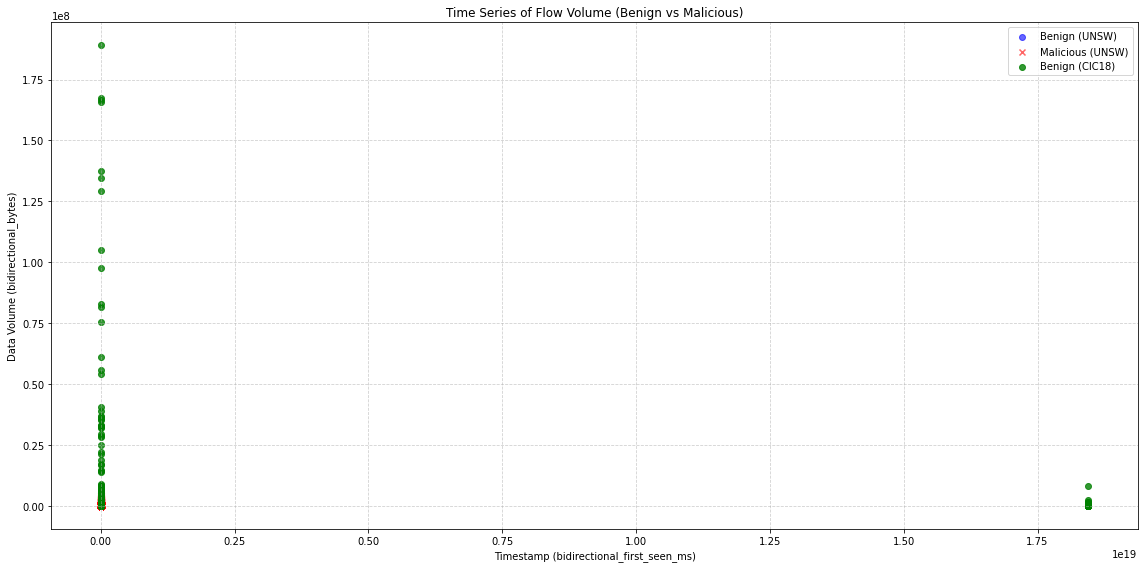

In [55]:
plt.figure(figsize=(16,8))

# Fluxos UNSW normais
subset = df_unsw_integrado[(df_unsw_integrado['binary'] == 0) & (df_unsw_integrado['source'] == 'unsw')]
plt.scatter(subset['bidirectional_first_seen_ms'],
            subset['bidirectional_bytes'],
            label="Benign (UNSW)", c='blue', alpha=0.6)

# Fluxos UNSW maliciosos
subset = df_unsw_integrado[(df_unsw_integrado['binary'] == 1) & (df_unsw_integrado['source'] == 'unsw')]
plt.scatter(subset['bidirectional_first_seen_ms'],
            subset['bidirectional_bytes'],
            label="Malicious (UNSW)", c='red', marker='x', alpha=0.6)

# Fluxos CIC18 inseridos
subset = df_unsw_integrado[df_unsw_integrado['source'] == 'cic18_10_benign']
plt.scatter(subset['bidirectional_first_seen_ms'],
            subset['bidirectional_bytes'],
            label="Benign (CIC18)", c='green', alpha=0.8)

plt.title("Time Series of Flow Volume (Benign vs Malicious)")
plt.xlabel("Timestamp (bidirectional_first_seen_ms)")
plt.ylabel("Data Volume (bidirectional_bytes)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [57]:
print(df_unsw_integrado.shape)
print(cic18_test.shape)

(932610, 72)
(4089071, 71)
(3987448, 71)


In [58]:
df_unsw_integrado.drop(['source'], axis=1, inplace=True)

In [59]:
print(df_unsw_integrado.shape)
print(cic18_test.shape)

(932610, 71)
(4089071, 71)
(3987448, 71)


## Split - Treino e Teste

In [61]:
X_unsw = df_unsw_integrado.drop(['binary'], axis=1)
X_cic18 = cic18_test.drop(['binary'], axis=1)

In [62]:
print(X_unsw.shape)
print(X_cic18.shape)

(932610, 70)
(4089071, 70)
(3987448, 70)


In [64]:
y_unsw = df_unsw_integrado['binary']
y_cic18 = cic18_test['binary']

In [65]:
print(y_unsw.shape)
print(y_cic18.shape)

(932610,)
(4089071,)
(3987448,)


In [66]:
X_train, X_test, y_train, y_test = train_test_split(X_unsw, y_unsw, test_size = 0.8, random_state=42)

## Normalização

In [67]:
type(X_train)

pandas.core.frame.DataFrame

In [68]:
X_train.head()

,src_port,dst_port,protocol,bidirectional_first_seen_ms,bidirectional_last_seen_ms,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,src2dst_first_seen_ms,src2dst_last_seen_ms,...,dst2src_ece_packets,dst2src_urg_packets,dst2src_ack_packets,dst2src_psh_packets,dst2src_rst_packets,dst2src_fin_packets,application_name,application_category_name,application_is_guessed,application_confidence
46907,7215.0,111.0,17.0,1.421949e+12,1.421949e+12,87.0,8.0,1016.0,1.421949e+09,1.421949e+09,...,0.0,0.0,0.0,0.0,0.0,0.0,58.0,3.0,0.0,6.0
697123,50080.0,443.0,6.0,1.519224e+12,1.519224e+12,170888.0,61.0,26034.0,1.519224e+12,1.519224e+12,...,0.0,0.0,32.0,12.0,0.0,1.0,155.0,0.0,0.0,6.0
304642,2887.0,6881.0,6.0,1.424232e+12,1.424232e+12,5659.0,920.0,790834.0,1.424232e+09,1.424232e+09,...,0.0,0.0,600.0,274.0,0.0,2.0,4.0,5.0,0.0,6.0
666562,51341.0,443.0,6.0,1.519141e+12,1.519141e+12,171145.0,31.0,6970.0,1.519141e+12,1.519141e+12,...,0.0,0.0,14.0,6.0,0.0,1.0,155.0,25.0,0.0,6.0
38334,28968.0,53.0,17.0,1.421947e+12,1.421947e+12,1.0,4.0,356.0,1.421947e+09,1.421947e+09,...,0.0,0.0,0.0,0.0,0.0,0.0,15.0,11.0,0.0,6.0


In [69]:
X_train.describe().round(2)

,src_port,dst_port,protocol,bidirectional_first_seen_ms,bidirectional_last_seen_ms,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,src2dst_first_seen_ms,src2dst_last_seen_ms,...,dst2src_ece_packets,dst2src_urg_packets,dst2src_ack_packets,dst2src_psh_packets,dst2src_rst_packets,dst2src_fin_packets,application_name,application_category_name,application_is_guessed,application_confidence
count,186522.00,186522.00,186522.00,1.865220e+05,1.865220e+05,186522.00,186522.00,1.865220e+05,1.865220e+05,1.865220e+05,...,186522.00,186522.0,186522.00,186522.00,186522.00,186522.00,186522.00,186522.00,186522.00,186522.00
mean,39703.27,8262.97,11.28,4.064874e+16,4.064874e+16,7034.69,67.57,3.144685e+04,4.064788e+16,4.064788e+16,...,0.03,0.0,30.18,14.13,0.05,0.92,70.31,12.88,0.07,4.92
std,19923.37,15887.76,17.59,8.649633e+17,8.649633e+17,42310.88,5251.30,4.829853e+05,8.649634e+17,8.649634e+17,...,0.19,0.0,190.85,44.52,0.25,0.96,49.40,6.71,0.25,2.23
min,0.00,0.00,0.00,1.421927e+12,1.421927e+12,0.00,1.00,4.200000e+01,1.421927e+09,1.421927e+09,...,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,23139.25,53.00,6.00,1.424224e+12,1.424224e+12,1.00,4.00,3.560000e+02,1.424224e+09,1.424224e+09,...,0.00,0.0,0.00,0.00,0.00,0.00,17.00,5.00,0.00,6.00
50%,47995.00,443.00,6.00,1.424252e+12,1.424252e+12,35.00,16.00,2.289000e+03,1.424252e+09,1.424252e+09,...,0.00,0.0,7.00,1.00,0.00,1.00,65.00,15.00,0.00,6.00
75%,55620.75,6881.00,17.00,1.519227e+12,1.519227e+12,984.00,46.00,1.222800e+04,1.519227e+12,1.519227e+12,...,0.00,0.0,22.00,8.00,0.00,2.00,108.00,17.00,0.00,6.00
max,65535.00,65534.00,255.00,1.844674e+19,1.844674e+19,1799951.00,2264875.00,1.676008e+08,1.844674e+19,1.844674e+19,...,3.00,0.0,49473.00,625.00,5.00,10.00,189.00,25.00,1.00,6.00


In [70]:
scaler = StandardScaler()

In [71]:
X_train_scaled = scaler.fit_transform(X_train)

In [72]:
X_test_scaled = scaler.transform(X_test)

In [73]:
X_cic18_scaled = scaler.transform(X_cic18)

In [75]:
type(X_train_scaled)

numpy.ndarray

In [76]:
type(X_test_scaled)

numpy.ndarray

In [77]:
type(X_cic18_scaled)

numpy.ndarray

In [79]:
X_train_scaled

array([[-1.63066574, -0.5130989 ,  0.32526093, ..., -1.47285406,
        -0.26550918,  0.48471401],
       [ 0.5208337 , -0.49220226, -0.30001103, ..., -1.9202533 ,
        -0.26550918,  0.48471401],
       [-1.84789867, -0.08698366, -0.30001103, ..., -1.1745879 ,
        -0.26550918,  0.48471401],
       ...,
       [-0.87225779, -0.51870071, -0.30001103, ...,  0.01847673,
        -0.26550918,  0.48471401],
       [ 0.82655593, -0.49207637, -0.30001103, ...,  1.21154136,
         3.76634812, -1.76086802],
       [-0.90518404, -0.51108476, -0.30001103, ..., -1.02545483,
        -0.26550918,  0.48471401]])

In [80]:
model = XGBClassifier(eval_metric='logloss',
                      n_estimators=300,  # Número de árvores na floresta.
                      max_depth=10,      # Profundidade máxima das árvores.
                      objective='binary:logistic', # Para modelo binário
                      learning_rate=0.05,  # Taxa de aprendizado (trade-off entre velocidade e performance)
                      subsample=0.8,  # Proporção dos dados usados em cada árvore
                      colsample_bytree=0.8,  # Fração de features usadas por árvore
                      gamma=0.5,         # Redução mínima da perda para realizar um split (regularização)
                      random_state=42,  # executar o código várias vezes com o mesmo random_state
                      use_label_encoder=False  # informa ao XGBoost para usar o padrão mais comum
                     )

In [81]:
# Treina o modelo final em dados de treinamento completo
model.fit(X_train_scaled, y_train)

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.8,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', gamma=0.5, gpu_id=-1,
              grow_policy='depthwise', importance_type=None,
              interaction_constraints='', learning_rate=0.05, max_bin=256,
              max_cat_to_onehot=4, max_delta_step=0, max_depth=10, max_leaves=0,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=300, n_jobs=0, num_parallel_tree=1, predictor='auto',
              random_state=42, reg_alpha=0, reg_lambda=1, ...)

## Feature Importance

In [82]:
# Obter a importância das features do modelo
importances = model.feature_importances_
feature_names = X_unsw.columns

In [83]:
# Criar DataFrame e ordenar por importância
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)  # Para usar barplot horizontal

In [84]:
# Imprimir todas as features ordenadas
print("Importância das Features (completa):")
for index, row in feature_importance_df[::-1].iterrows():
    print(f"{row['Feature']:30s}{row['Importance']:.4f}")

Importância das Features (completa):
src2dst_last_seen_ms          0.7945
bidirectional_first_seen_ms   0.0627
bidirectional_last_seen_ms    0.0339
dst2src_max_ps                0.0283
dst2src_min_ps                0.0200
src2dst_first_seen_ms         0.0138
dst2src_psh_packets           0.0082
bidirectional_min_piat_ms     0.0047
bidirectional_min_ps          0.0044
dst2src_mean_ps               0.0036
dst2src_last_seen_ms          0.0034
src2dst_min_ps                0.0028
bidirectional_psh_packets     0.0022
dst2src_first_seen_ms         0.0020
src2dst_min_piat_ms           0.0011
bidirectional_rst_packets     0.0010
application_confidence        0.0007
src2dst_psh_packets           0.0007
src2dst_rst_packets           0.0006
bidirectional_mean_piat_ms    0.0006
bidirectional_syn_packets     0.0006
src2dst_bytes                 0.0005
application_name              0.0005
dst2src_stddev_ps             0.0005
application_category_name     0.0005
protocol                      0.0004
d

In [85]:
# Selecionar as 10 mais importantes
top10_df = feature_importance_df.tail(10)

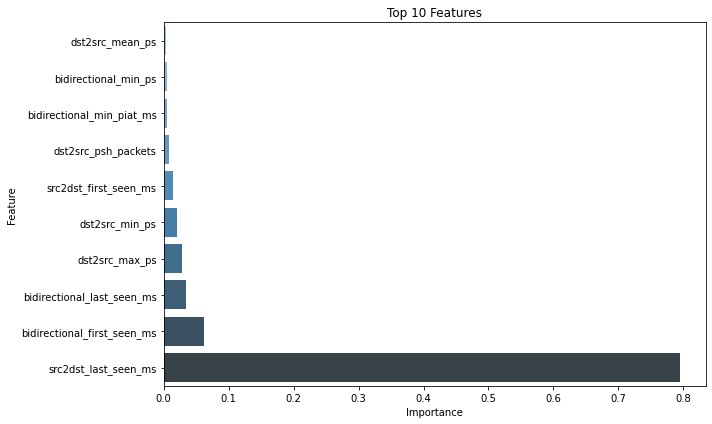

In [86]:
# Gráfico de barras horizontal com seaborn
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top10_df,
    x='Importance',
    y='Feature',
    palette='Blues_d'
)
plt.title("Top 10 Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Predição

In [87]:
y_pred = model.predict(X_test_scaled)

In [88]:
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1 ]

## Métricas Intraset

In [89]:
# Calcula a matriz de funsão
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[663196  18643]
 [  3584  60665]]


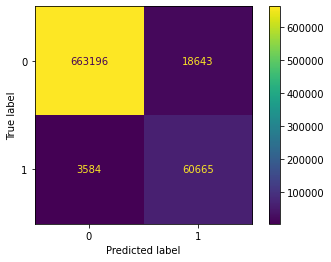

In [90]:
ConfusionMatrixDisplay.from_estimator(model, X_test_scaled, y_test)
plt.show()

In [91]:
# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

Classification Report:
              precision    recall  f1-score   support

           0     0.9946    0.9727    0.9835    681839
           1     0.7649    0.9442    0.8452     64249

    accuracy                         0.9702    746088
   macro avg     0.8798    0.9584    0.9143    746088
weighted avg     0.9748    0.9702    0.9716    746088



In [92]:
# Individual Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
auc_roc = roc_auc_score(y_test, y_pred_proba)

In [93]:
print(f"Accuracy (Macro): {accuracy:.4f}")
print(f"Precision (Macro): {precision:.4f}")
print(f"Recall (Macro): {recall:.4f}")
print(f"F1-Score (Macro): {f1:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

Accuracy (Macro): 0.9702
Precision (Macro): 0.8798
Recall (Macro): 0.9584
F1-Score (Macro): 0.9143
AUC-ROC: 0.9896


In [94]:
# Calculate FAR (False Acceptance Rate) = FP / (FP + TN)
tn, fp, fn, tp = cm.ravel()
far = fp / (fp + tn) if (fp + tn) > 0 else 0
print(f"FAR (False Acceptance Rate): {far:.4f}")

FAR (False Acceptance Rate): 0.0273


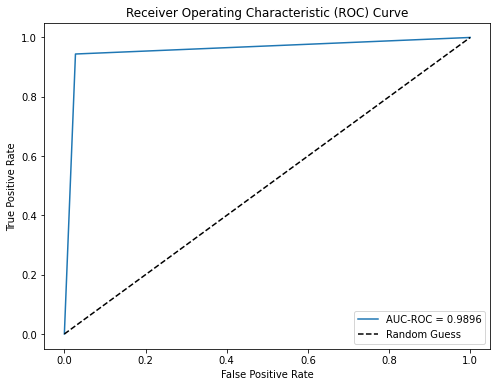

In [95]:
# Visualizando a Curva ROC
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_pred)

#aumentar tamanho do gráfico
fig, ax = plt.subplots(figsize=(8,6))

#criar gráfico
plt.plot(false_positive_rate, true_positive_rate, label=f'AUC-ROC = {auc_roc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label=f'Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()

#exibir o gráfico
plt.show();

In [96]:
ap_score_unsw = average_precision_score(y_test, y_pred, pos_label=1)
print(f"AUC-PR / Average Precision: {ap_score_unsw:.4f}")

AUC-PR / Average Precision: 0.7271


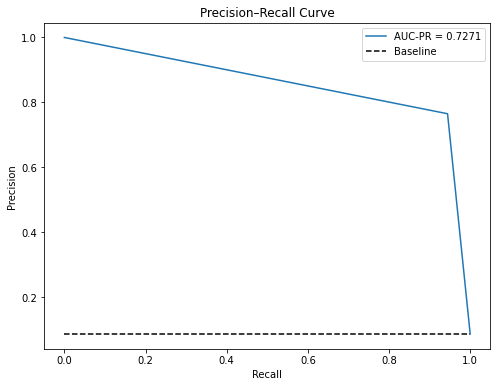

In [97]:
plt.figure(figsize=(8,6))
prec_unsw, rec_unsw, _ = precision_recall_curve(y_test, y_pred, pos_label=1)
plt.plot(rec_unsw, prec_unsw, label=f'AUC-PR = {ap_score_unsw:.4f}')
baseline = np.sum(y_test) / len(y_test)  # proporção de positivos
plt.plot([0, 1], [baseline, baseline], 'k--', label='Baseline ')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.legend()
plt.title('Precision–Recall Curve'); plt.show()

## Predição (generalização CIC18)

In [98]:
y_pred_cic18 = model.predict(X_cic18_scaled)

In [99]:
y_pred_proba_cic18 = model.predict_proba(X_cic18_scaled)[:, 1 ]

## Métricas Interset (generalização CIC18)

In [100]:
# Calcula a matriz de funsão
cm_cic18 = confusion_matrix(y_cic18, y_pred_cic18)
print("Confusion Matrix:")
print(cm_cic18)

Confusion Matrix:
[[3355063       0]
 [ 734008       0]]


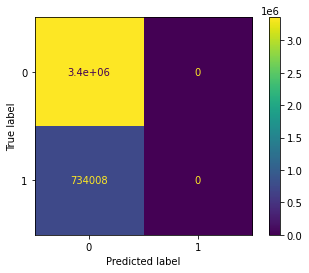

In [101]:
ConfusionMatrixDisplay.from_estimator(model, X_cic18_scaled, y_cic18)
plt.show()

In [102]:
# Classification Report
print("Classification Report:")
print(classification_report(y_cic18, y_pred_cic18, digits=4, zero_division=0))

Classification Report:
              precision    recall  f1-score   support

           0     0.8205    1.0000    0.9014   3355063
           1     0.0000    0.0000    0.0000    734008

    accuracy                         0.8205   4089071
   macro avg     0.4102    0.5000    0.4507   4089071
weighted avg     0.6732    0.8205    0.7396   4089071



In [103]:
# Individual Metrics
accuracy_cic18 = accuracy_score(y_cic18, y_pred_cic18)
precision_cic18 = precision_score(y_cic18, y_pred_cic18, average='macro', zero_division=0)
recall_cic18 = recall_score(y_cic18, y_pred_cic18, average='macro', zero_division=0)
f1_cic18 = f1_score(y_cic18, y_pred_cic18, average='macro')
auc_roc_cic18 = roc_auc_score(y_cic18, y_pred_proba_cic18)

In [104]:
print(f"Accuracy (Macro): {accuracy_cic18:.4f}")
print(f"Precision (Macro): {precision_cic18:.4f}")
print(f"Recall (Macro): {recall_cic18:.4f}")
print(f"F1-Score (Macro): {f1_cic18:.4f}")
print(f"AUC-ROC: {auc_roc_cic18:.4f}")

Accuracy (Macro): 0.8205
Precision (Macro): 0.4102
Recall (Macro): 0.5000
F1-Score (Macro): 0.4507
AUC-ROC: 0.5051


In [105]:
# Calculate FAR (False Acceptance Rate) = FP / (FP + TN)
tn_cic18, fp_cic18, fn_cic18, tp_cic18 = cm_cic18.ravel()
far_cic18 = fp_cic18 / (fp_cic18 + tn_cic18) if (fp_cic18 + tn_cic18) > 0 else 0
print(f"FAR (False Acceptance Rate): {far_cic18:.4f}")

FAR (False Acceptance Rate): 0.0000


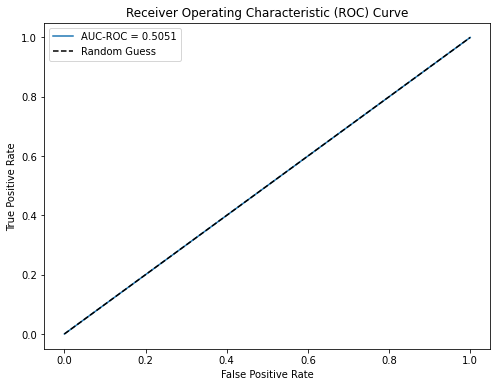

In [106]:
# Visualizando a Curva ROC
false_positive_rate_cic18, true_positive_rate_cic18, thresholds_cic18 = roc_curve(y_cic18, y_pred_cic18)

#aumentar tamanho do gráfico
fig_cic18, ax_cic18 = plt.subplots(figsize=(8,6))

#criar gráfico
plt.plot(false_positive_rate_cic18, true_positive_rate_cic18, label=f'AUC-ROC = {auc_roc_cic18:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()

#exibir o gráfico
plt.show();

In [107]:
ap_score_cic18 = average_precision_score(y_cic18, y_pred_cic18, pos_label=1)
print(f"AUC-PR / Average Precision: {ap_score_cic18:.4f}")

AUC-PR / Average Precision: 0.1795


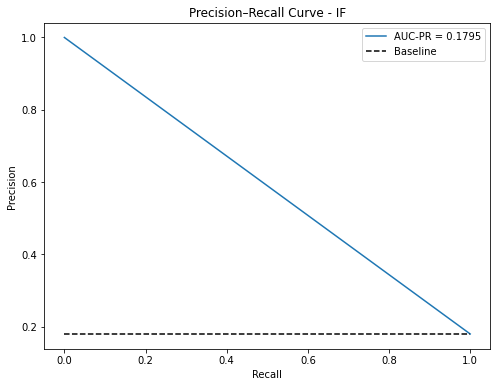

In [108]:
plt.figure(figsize=(8,6))
prec_cic18, rec_cic18, _ = precision_recall_curve(y_cic18, y_pred_cic18, pos_label=1)
plt.plot(rec_cic18, prec_cic18, label=f'AUC-PR = {ap_score_cic18:.4f}')
baseline = np.sum(y_cic18) / len(y_cic18)  # proporção de positivos
plt.plot([0, 1], [baseline, baseline], 'k--', label='Baseline ')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.legend()
plt.title('Precision–Recall Curve - IF'); plt.show()